# 04 — Modelo Random Forest con Features Espaciales

**TFM — Valoración Inmobiliaria Masiva: SLX vs Machine Learning**

---

## ¿Qué hace este notebook?

Entrenamos un **Random Forest** para predecir el precio de las viviendas de King County.
El punto central de este notebook es demostrar el **valor de las features espaciales**
que construimos en el notebook 03: compararemos un RF entrenado solo con las 18 variables
originales (baseline) frente a uno entrenado con las 30 variables enriquecidas espacialmente.

Después, el mejor modelo se optimiza mediante búsqueda de hiperparámetros y se evalúa
sobre el conjunto de test. Para cerrar el análisis, calculamos el **Índice de Moran's I
de los residuos**: si el RF ha aprendido la estructura espacial del mercado, los errores
ya no deberían concentrarse geográficamente (Moran's I → 0).

## Estructura del notebook

1. **Setup** — imports, rutas, semilla de reproducibilidad
2. **Carga de datos** — X_train_spatial, X_test_spatial, y_train, y_test
3. **Baseline sin features espaciales** — RF con las 18 columnas originales
4. **RF con features espaciales** — RF con las 30 columnas (18 + 12 lags KNN)
5. **Optimización de hiperparámetros** — RandomizedSearchCV, 5-fold CV
6. **Evaluación final en test** — RMSE, MAE, R² en escala log y en dólares
7. **Importancia de variables** — ¿cuánto aporta cada feature?
8. **Análisis de residuos** — distribución + Moran's I espacial
9. **Guardado** — modelo y métricas para el notebook de comparativa

In [1]:
import sys
import os
import warnings
warnings.filterwarnings('ignore')
sys.path.insert(0, '../src')

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import seaborn as sns

from sklearn.ensemble import RandomForestRegressor
from sklearn.model_selection import RandomizedSearchCV, cross_val_score
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

from utils import set_plot_style, evaluate_model, save_metrics, compute_moran_i

set_plot_style()

PROCESSED = '../data/processed/'
FIGURES   = '../outputs/figures/'
METRICS   = '../outputs/metrics/'
MODELS    = '../outputs/models/'
for d in [FIGURES, METRICS, MODELS]:
    os.makedirs(d, exist_ok=True)

SEED = 42
np.random.seed(SEED)

print('Entorno listo.')
print(f'Semilla de reproducibilidad: {SEED}')

Entorno listo.
Semilla de reproducibilidad: 42


In [2]:
# Carga de los datasets generados por los notebooks 02 y 03
X_train_spatial = pd.read_csv(PROCESSED + 'X_train_spatial.csv')
X_test_spatial  = pd.read_csv(PROCESSED + 'X_test_spatial.csv')
X_train_orig    = pd.read_csv(PROCESSED + 'X_train.csv')   # baseline sin lags
X_test_orig     = pd.read_csv(PROCESSED + 'X_test.csv')
y_train         = pd.read_csv(PROCESSED + 'y_train.csv').squeeze()
y_test          = pd.read_csv(PROCESSED + 'y_test.csv').squeeze()
coords_test     = pd.read_csv(PROCESSED + 'coords_test.csv').values

# Columnas originales vs nuevas features espaciales
lag_cols  = [c for c in X_train_spatial.columns if c.startswith('lag_')]
orig_cols = [c for c in X_train_spatial.columns if not c.startswith('lag_')]

print(f'X_train_spatial: {X_train_spatial.shape}')
print(f'X_test_spatial:  {X_test_spatial.shape}')
print(f'y_train:         {y_train.shape}   |  rango: [{y_train.min():.2f}, {y_train.max():.2f}]')
print(f'y_test:          {y_test.shape}')
print(f'\nFeatures originales ({len(orig_cols)}): {orig_cols}')
print(f'\nFeatures lag        ({len(lag_cols)}):  {lag_cols}')

X_train_spatial: (17289, 30)
X_test_spatial:  (4323, 30)
y_train:         (17289,)   |  rango: [11.23, 15.86]
y_test:          (4323,)

Features originales (18): ['bedrooms', 'bathrooms', 'sqft_living', 'sqft_lot', 'floors', 'waterfront', 'view', 'condition', 'grade', 'sqft_above', 'zipcode', 'lat', 'long', 'sqft_living15', 'sqft_lot15', 'sale_month', 'house_age', 'renovated']

Features lag        (12):  ['lag_bedrooms_k15', 'lag_bathrooms_k15', 'lag_sqft_living_k15', 'lag_sqft_lot_k15', 'lag_floors_k15', 'lag_waterfront_k15', 'lag_view_k15', 'lag_condition_k15', 'lag_grade_k15', 'lag_sqft_above_k15', 'lag_house_age_k15', 'lag_renovated_k15']


## 1. Baseline: Random Forest sin features espaciales

Antes de añadir los spatial lags, entrenamos un RF con los hiperparámetros por defecto
usando solo las **18 features originales**. Este modelo representa la capacidad predictiva
de un RF estándar "espacialmente ciego". Comparar su rendimiento con el modelo enriquecido
cuantifica exactamente cuánto aportan las features espaciales.

In [3]:
# RF baseline: 18 features originales, hiperparámetros por defecto
rf_baseline = RandomForestRegressor(n_estimators=200, random_state=SEED, n_jobs=-1)
rf_baseline.fit(X_train_orig, y_train)

y_pred_baseline = rf_baseline.predict(X_test_orig)
metrics_baseline = evaluate_model(y_test.values, y_pred_baseline, 'RF Baseline (sin features espaciales)')


  RF Baseline (sin features espaciales)
  RMSE (log):    0.1772
  MAE  (log):    0.1263
  R²:            0.8901
  RMSE (€/$):    138,441
  MAE  (€/$):    72,316
  MAPE (%):      12.82%



## 2. Random Forest con features espaciales

Añadimos las 12 columnas de spatial lag calculadas en el notebook 03. El modelo ahora tiene
acceso a información del vecindario de cada vivienda: precio medio, tamaño, calidad constructiva,
estado de conservación y nivel socioeconómico del entorno.

In [4]:
# RF con 30 features (18 originales + 12 lags), mismo n_estimators para comparación justa
rf_spatial = RandomForestRegressor(n_estimators=200, random_state=SEED, n_jobs=-1)
rf_spatial.fit(X_train_spatial, y_train)

y_pred_spatial = rf_spatial.predict(X_test_spatial)
metrics_spatial = evaluate_model(y_test.values, y_pred_spatial, 'RF con Features Espaciales (sin tuning)')

# Comparación directa baseline vs espacial
print('\n--- Impacto de las features espaciales ---')
mejora_r2   = metrics_spatial['R2']   - metrics_baseline['R2']
mejora_rmse = metrics_baseline['RMSE_log'] - metrics_spatial['RMSE_log']
print(f'  Mejora en R²:        +{mejora_r2:.4f}')
print(f'  Reducción de RMSE:   -{mejora_rmse:.4f} (log scale)')


  RF con Features Espaciales (sin tuning)
  RMSE (log):    0.1774
  MAE  (log):    0.1267
  R²:            0.8899
  RMSE (€/$):    140,403
  MAE  (€/$):    72,570
  MAPE (%):      12.86%


--- Impacto de las features espaciales ---
  Mejora en R²:        +-0.0002
  Reducción de RMSE:   --0.0002 (log scale)


## 3. Optimización de hiperparámetros (RandomizedSearchCV)

El Random Forest tiene varios hiperparámetros que controlan la complejidad y diversidad
del ensemble:

| Hiperparámetro | ¿Qué controla? |
|---|---|
| `n_estimators` | Número de árboles. Más árboles → menor varianza, mayor coste computacional |
| `max_depth` | Profundidad máxima de cada árbol. Limitar evita sobreajuste |
| `min_samples_split` | Mínimo de muestras para dividir un nodo |
| `min_samples_leaf` | Mínimo de muestras en una hoja (controla suavizado) |
| `max_features` | Número de features consideradas en cada split (introduce diversidad entre árboles) |

Usamos **RandomizedSearchCV** con 5-fold cross-validation y 30 combinaciones aleatorias.
La métrica de optimización es el RMSE en escala logarítmica (equivalente a minimizar el
error porcentual en escala original, que es lo que más importa en valoración inmobiliaria).

In [5]:
param_dist = {
    'n_estimators':      [200, 300, 400, 500],
    'max_depth':         [None, 15, 25, 35],
    'min_samples_split': [2, 5, 10],
    'min_samples_leaf':  [1, 2, 4],
    'max_features':      ['sqrt', 'log2', 0.3],
}

search = RandomizedSearchCV(
    RandomForestRegressor(random_state=SEED, n_jobs=-1),
    param_distributions=param_dist,
    n_iter=30,
    cv=5,
    scoring='neg_root_mean_squared_error',
    random_state=SEED,
    verbose=1,
    n_jobs=-1
)

print('Iniciando búsqueda de hiperparámetros (30 iteraciones × 5-fold CV)...')
search.fit(X_train_spatial, y_train)

print(f'\nMejores hiperparámetros encontrados:')
for k, v in search.best_params_.items():
    print(f'  {k}: {v}')
print(f'\nMejor RMSE (CV, log scale): {-search.best_score_:.4f}')

Iniciando búsqueda de hiperparámetros (30 iteraciones × 5-fold CV)...
Fitting 5 folds for each of 30 candidates, totalling 150 fits

Mejores hiperparámetros encontrados:
  n_estimators: 500
  min_samples_split: 2
  min_samples_leaf: 1
  max_features: 0.3
  max_depth: None

Mejor RMSE (CV, log scale): 0.1751


## 4. Evaluación final del modelo optimizado en test

Usamos el mejor modelo encontrado por la búsqueda para predecir sobre el conjunto de test.
Recordamos que el test set **no ha participado en ningún paso de entrenamiento ni tuning**:
ni en el ajuste del KNN de spatial features, ni en la validación cruzada, ni en el fit final.

In [6]:
# Modelo final optimizado
rf_final = search.best_estimator_

y_pred_final = rf_final.predict(X_test_spatial)
metrics_final = evaluate_model(y_test.values, y_pred_final, 'RF Final (con features espaciales, tuning)')

# Tabla comparativa de los tres modelos
print('\n=== TABLA COMPARATIVA ===')
comparativa = pd.DataFrame([metrics_baseline, metrics_spatial, metrics_final]).set_index('modelo')
display(comparativa)


  RF Final (con features espaciales, tuning)
  RMSE (log):    0.1740
  MAE  (log):    0.1241
  R²:            0.8941
  RMSE (€/$):    140,493
  MAE  (€/$):    71,637
  MAPE (%):      12.60%


=== TABLA COMPARATIVA ===


,RMSE_log,MAE_log,R2,RMSE_orig,MAE_orig,MAPE_orig
modelo,,,,,,
RF Baseline (sin features espaciales),0.177239,0.126337,0.890120,138440.72,72315.80,0.1282
RF con Features Espaciales (sin tuning),0.177420,0.126655,0.889895,140402.86,72569.50,0.1286
"RF Final (con features espaciales, tuning)",0.174026,0.124135,0.894068,140492.89,71636.97,0.1260


## 5. Importancia de variables

El Random Forest calcula automáticamente la importancia de cada feature: mide cuánto
reduce la impureza (varianza en regresión) cuando se usa esa variable para dividir
los nodos de los árboles. Una feature con importancia alta aparece frecuentemente en los
splits más altos del árbol, donde las decisiones tienen mayor impacto.

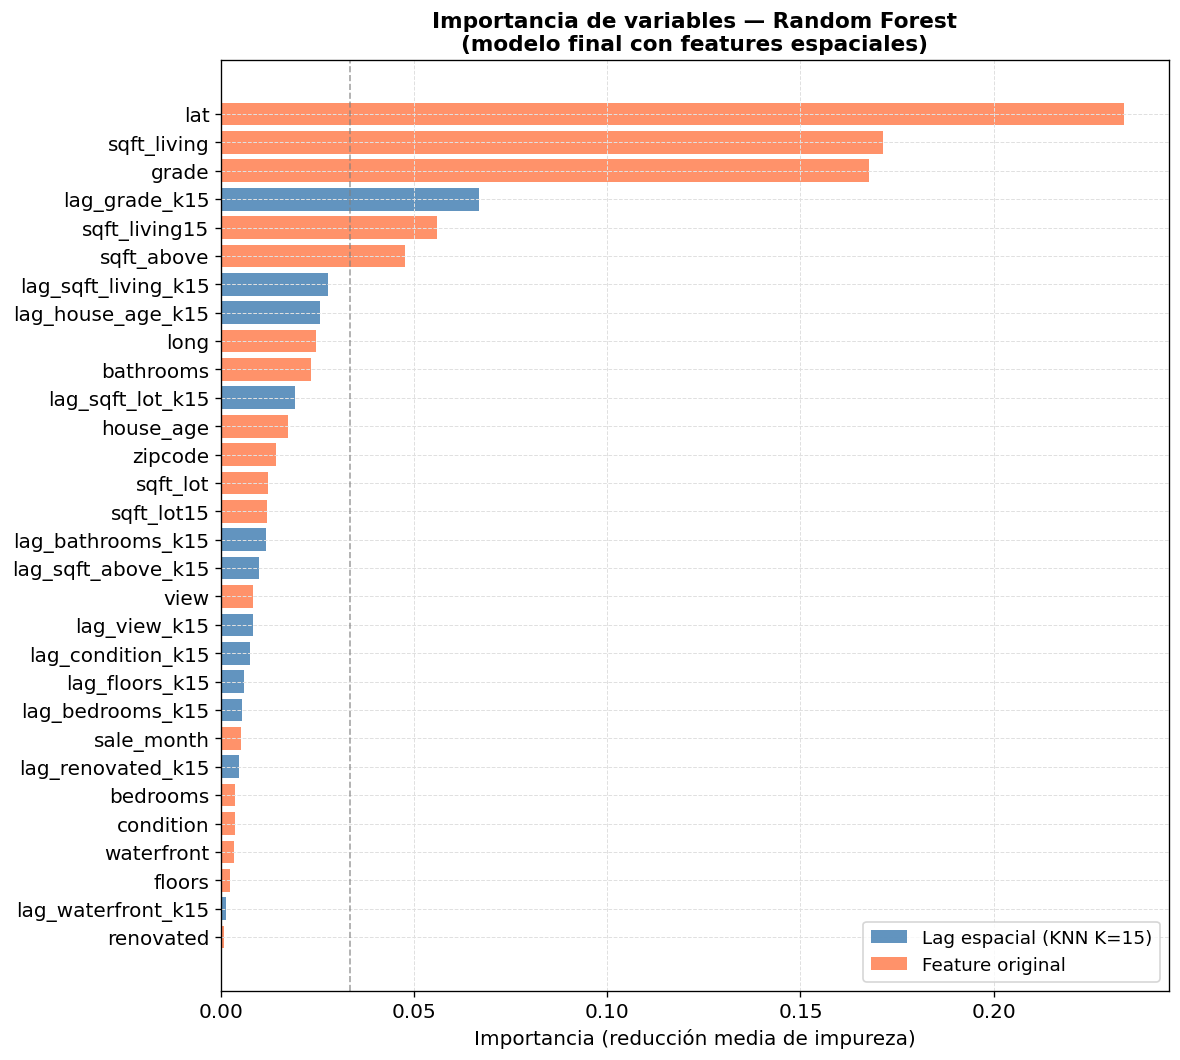


Top 5 features más importantes:
  [orig] lat: 0.2337
  [orig] sqft_living: 0.1714
  [orig] grade: 0.1679
  [LAG] lag_grade_k15: 0.0667
  [orig] sqft_living15: 0.0558


In [7]:
# Importancia de variables del modelo final
importances = pd.Series(rf_final.feature_importances_, index=X_train_spatial.columns)
importances = importances.sort_values(ascending=True)

# Colorear diferente las features lag vs originales
colors = ['steelblue' if c.startswith('lag_') else 'coral' for c in importances.index]

fig, ax = plt.subplots(figsize=(10, 9))
bars = ax.barh(importances.index, importances.values, color=colors, alpha=0.85)

# Leyenda manual para los colores
from matplotlib.patches import Patch
legend_elements = [
    Patch(facecolor='steelblue', alpha=0.85, label='Lag espacial (KNN K=15)'),
    Patch(facecolor='coral',     alpha=0.85, label='Feature original')
]
ax.legend(handles=legend_elements, fontsize=11, loc='lower right')

ax.set_xlabel('Importancia (reducción media de impureza)', fontsize=12)
ax.set_title('Importancia de variables — Random Forest\n(modelo final con features espaciales)',
             fontsize=13, fontweight='bold')

# Línea vertical en la importancia media
mean_imp = importances.mean()
ax.axvline(mean_imp, color='gray', linestyle='--', linewidth=1, alpha=0.7,
           label=f'Media = {mean_imp:.3f}')

plt.tight_layout()
plt.savefig(FIGURES + '04_rf_feature_importance.png')
plt.show()

print(f'\nTop 5 features más importantes:')
for feat, imp in importances.tail(5)[::-1].items():
    tipo = 'LAG' if feat.startswith('lag_') else 'orig'
    print(f'  [{tipo}] {feat}: {imp:.4f}')

## 6. Análisis de residuos

Los residuos (errores de predicción) son la diferencia entre el valor real y el predicho.
Para un buen modelo:
- Su distribución debe ser **centrada en cero** y aproximadamente normal
- **No deben tener estructura espacial**: si los errores se concentran en ciertas zonas
  geográficas, significa que el modelo no ha aprendido toda la información espacial disponible

Para medir si quedan patrones espaciales en los residuos, calculamos el **Índice de Moran's I**.
Si el RF ha absorbido la información espacial gracias a los lags, el Moran's I de los
residuos debería ser cercano a 0 (sin autocorrelación) vs el 0.84 que tenía el precio bruto.

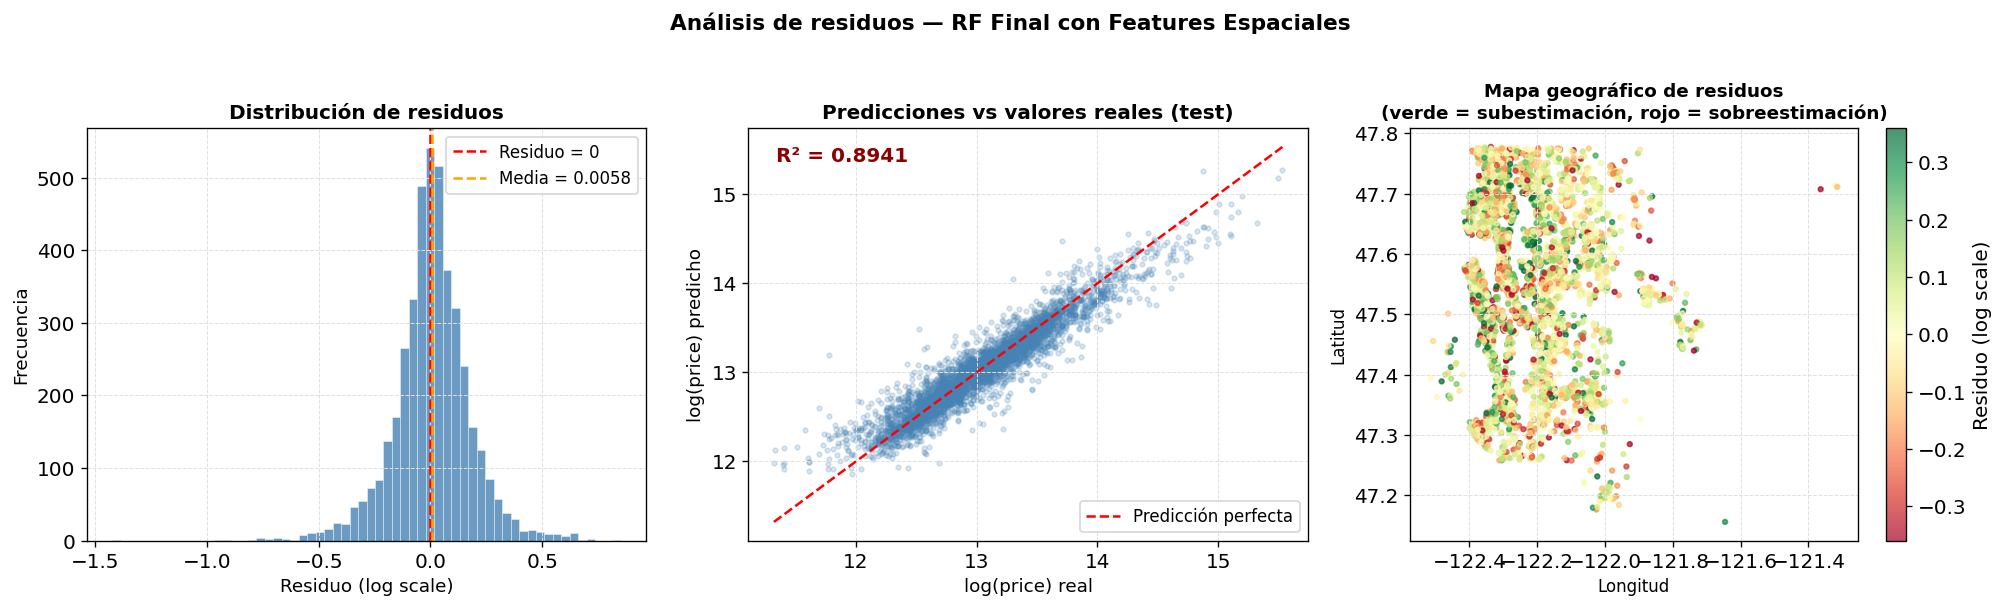

Estadísticas de residuos:
  Media:   0.0058  (idealmente ≈ 0)
  Std:     0.1739
  Máx:     0.8519
  Mín:     -1.4245


In [8]:
residuos = y_test.values - y_pred_final

fig, axes = plt.subplots(1, 3, figsize=(17, 5))

# Panel 1: Distribución de residuos
axes[0].hist(residuos, bins=60, color='steelblue', alpha=0.8, edgecolor='white', linewidth=0.3)
axes[0].axvline(0, color='red', linewidth=1.5, linestyle='--', label='Residuo = 0')
axes[0].axvline(residuos.mean(), color='orange', linewidth=1.5, linestyle='--',
                label=f'Media = {residuos.mean():.4f}')
axes[0].set_xlabel('Residuo (log scale)', fontsize=11)
axes[0].set_ylabel('Frecuencia', fontsize=11)
axes[0].set_title('Distribución de residuos', fontsize=12, fontweight='bold')
axes[0].legend(fontsize=10)

# Panel 2: Predicciones vs valores reales
axes[1].scatter(y_test, y_pred_final, alpha=0.2, s=8, color='steelblue')
lims = [min(y_test.min(), y_pred_final.min()), max(y_test.max(), y_pred_final.max())]
axes[1].plot(lims, lims, 'r--', linewidth=1.5, label='Predicción perfecta')
r2_val = r2_score(y_test, y_pred_final)
axes[1].annotate(f'R² = {r2_val:.4f}', xy=(0.05, 0.92), xycoords='axes fraction',
                 fontsize=12, fontweight='bold', color='darkred')
axes[1].set_xlabel('log(price) real', fontsize=11)
axes[1].set_ylabel('log(price) predicho', fontsize=11)
axes[1].set_title('Predicciones vs valores reales (test)', fontsize=12, fontweight='bold')
axes[1].legend(fontsize=10)

# Panel 3: Mapa geográfico de residuos
sc = axes[2].scatter(
    coords_test[:, 1], coords_test[:, 0],
    c=residuos, cmap='RdYlGn', s=8, alpha=0.7,
    vmin=-np.percentile(np.abs(residuos), 95),
    vmax= np.percentile(np.abs(residuos), 95)
)
plt.colorbar(sc, ax=axes[2], label='Residuo (log scale)')
axes[2].set_title('Mapa geográfico de residuos\n(verde = subestimación, rojo = sobreestimación)',
                  fontsize=11, fontweight='bold')
axes[2].set_xlabel('Longitud', fontsize=10)
axes[2].set_ylabel('Latitud', fontsize=10)

plt.suptitle('Análisis de residuos — RF Final con Features Espaciales',
             fontsize=13, fontweight='bold', y=1.01)
plt.tight_layout()
plt.savefig(FIGURES + '04_rf_residuos.png', bbox_inches='tight')
plt.show()

print(f'Estadísticas de residuos:')
print(f'  Media:   {residuos.mean():.4f}  (idealmente ≈ 0)')
print(f'  Std:     {residuos.std():.4f}')
print(f'  Máx:     {residuos.max():.4f}')
print(f'  Mín:     {residuos.min():.4f}')

In [9]:
# Moran's I de los residuos del test (K=8 vecinos para la matriz de pesos)
# Si → 0: el modelo ha corregido la autocorrelación espacial
# Si sigue alto: quedan patrones geográficos sin capturar
print('Moran\'s I de los residuos del modelo RF final:')
moran_rf = compute_moran_i(residuos, coords_test, k=8)

print(f'\nReferencia: Moran\'s I de log(price) bruto (EDA) = 0.84')
if moran_rf['moran_i'] is not None:
    reduccion = (0.84 - moran_rf['moran_i']) / 0.84 * 100
    print(f'Reducción de autocorrelación espacial: {reduccion:.1f}%')

Moran's I de los residuos del modelo RF final:
  Moran's I: 0.0797  (p-valor: 0.0010)

Referencia: Moran's I de log(price) bruto (EDA) = 0.84
Reducción de autocorrelación espacial: 90.5%


In [10]:
import joblib

# Guardar modelo
joblib.dump(rf_final, MODELS + 'rf_final.joblib')
print(f'Modelo guardado en: outputs/models/rf_final.joblib')

# Guardar métricas completas para el notebook de comparativa
metrics_final['moran_i_residuos'] = moran_rf['moran_i']
metrics_final['moran_i_pvalue']   = moran_rf['p_value']
metrics_final['best_params']      = search.best_params_

save_metrics(metrics_final, 'rf_final.json')

# Guardar predicciones de test para la comparativa final
pred_df = pd.DataFrame({'y_real': y_test.values, 'y_pred_rf': y_pred_final})
pred_df.to_csv(PROCESSED + 'pred_rf.csv', index=False)
print('Predicciones guardadas en: data/processed/pred_rf.csv')

Modelo guardado en: outputs/models/rf_final.joblib
Métricas guardadas en: /Users/jesusdelmoral/Documents/master/TFM/tfm-valoracion-inmobiliaria/notebooks/../src/../outputs/metrics/rf_final.json
Predicciones guardadas en: data/processed/pred_rf.csv
